# Graficzne metryki oceny modeli regresyjnych

Ocena modeli regresyjnych za pomocą **interpretacji graficznej** stanowi kluczowy etap analizy — uzupełnia standardowe metryki liczbowe (takie jak MSE, MAE czy R²) o możliwość **wizualnego zrozumienia błędów predykcji**, rozkładu reszt oraz jakości dopasowania.

---

**Cele interpretacji graficznej w regresji:**

* identyfikacja systematycznych błędów modelu (np. przeuczenie, niedouczenie),
* analiza rozrzutu predykcji względem wartości rzeczywistych,
* wykrycie niestacjonarności wariancji (heteroskedastyczności),
* ocena normalności i symetrii reszt,
* identyfikacja obserwacji odstających i wpływowych.

---

**Najczęściej stosowane wykresy regresyjne**:

**Wykres rzeczywista vs przewidywana (`y_true` vs `y_pred`)**

* Pokazuje, jak dobrze model przewiduje wartość celu.
* Idealnie: punkty leżą wzdłuż linii `y = x`.
* Umożliwia szybką ocenę dopasowania i kierunku błędów.

**Wykres reszt (`residuals` vs `y_pred`)**

* Pozwala sprawdzić, czy błędy są losowe.
* Brak struktury = dobre dopasowanie.
* Wzory lub wachlarzowy kształt → możliwe problemy (np. heteroskedastyczność, nieliniowość).

**Histogram reszt / rozkład reszt**

* Pozwala ocenić, czy reszty są rozkładem normalnym (oczekiwane w klasycznych założeniach).
* Sugeruje symetrię błędów i brak dużych odchyleń.

**Q-Q plot (Quantile-Quantile)**

* Porównuje rozkład reszt z rozkładem normalnym.
* Odchylenia od prostej → nienormalność błędów.

---

**Zastosowanie graficznej interpretacji w regresji**

* Lepsze zrozumienie **niedoskonałości dopasowania modelu** (czy błędy zależą od wartości celu?).
* Wskazanie konieczności:

  * transformacji zmiennych,
  * użycia innego modelu (np. nieliniowego),
  * redukcji wpływu obserwacji odstających.

---

**Podsumowanie**

Graficzna analiza regresji:

* nie zastępuje metryk liczbowych, ale je **uzupełnia**,
* pozwala zauważyć problemy niewidoczne w samych liczbach,
* jest **niezastąpionym narzędziem diagnostycznym**, zwłaszcza przy budowie i interpretacji modeli regresji liniowej i nieliniowej.

---

# Metryki liczbowe

**Metryki regresyjne – definicje**

* **MAE (Mean Absolute Error)**
  Średni błąd bezwzględny – odporny na wartości odstające.

  $$
  \text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
  $$

* **MSE (Mean Squared Error)**
  Średni błąd kwadratowy – wrażliwy na duże odchylenia.

  $$
  \text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
  $$

* **RMSE (Root Mean Squared Error)**
  Pierwiastek z MSE – pozwala interpretować błąd w jednostkach zmiennej zależnej.

  $$
  \text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
  $$

* **MedAE (Median Absolute Error)**
  Mediana bezwzględnych błędów – bardziej odporna na ekstremalne wartości niż MAE.

  $$
  \text{MedAE} = \text{mediana} \left( |y_i - \hat{y}_i| \right)
  $$

* **MAPE (Mean Absolute Percentage Error)**
  Średni procentowy błąd bezwzględny – pozwala porównać skuteczność modeli między zbiorami o różnych skalach.

  $$
  \text{MAPE} = \frac{100\%}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|
  $$

* **Max Error**
  Największy pojedynczy błąd predykcji (bezwzględny).

  $$
  \text{Max Error} = \max_i \left( |y_i - \hat{y}_i| \right)
  $$

* **R² (Coefficient of Determination)**
  Współczynnik determinacji – miara proporcji wariancji wyjaśnionej przez model.

  $$
  R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}
  $$

gdzie:

* $y_i$ – rzeczywista wartość dla obserwacji $i$,
* $\hat{y}_i$ – wartość przewidziana przez model,
* $n$ – liczba obserwacji.


# Przykład

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import scipy.stats as stats

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import median_absolute_error, mean_absolute_percentage_error, max_error

In [2]:
# Ustawienia wykresów
plt.style.use("default")  # lub 'seaborn-v0_8-whitegrid' jeśli chcesz siatkę

# Parametry wyglądu
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8,
    "grid.color": "gray",
    "grid.linestyle": "--",
    "grid.linewidth": 0.7,
    "grid.alpha": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "axes.titleweight": "normal",
    "axes.labelweight": "normal",
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "font.family": "sans-serif",
})

# Dodatkowo: usunięcie ramek z wykresów
sns.set_context("notebook", font_scale=1.0)
sns.despine()

<Figure size 768x576 with 0 Axes>

## Dane: California housing

<div style="text-align: center;"><img src=".\\Images\\California_Housing.png" alt="California housing" width="400" height="120" style="margin: 10px;" /></div>

**Dane źródłowe**

Zbiór danych pochodzi z `sklearn.datasets.fetch_california_housing()`, a pierwotnie z **California Housing Survey (1990)**.

- Liczba rekordów: 20 640
- Liczba cech: 8
- Każdy wiersz odpowiada agregowanym danym dla małego obszaru geograficznego (block group)
- Dane zawierają m.in.:
  - średni wiek budynków,
  - średni dochód gospodarstwa domowego,
  - gęstość zaludnienia,
  - położenie geograficzne (szerokość, długość geograficzna),
  - liczba pokoi, sypialni itd.

---

**Zmienna docelowa**

- `MedHouseVal` – **mediana wartości domów** (w dziesiątkach tysięcy dolarów)

**Uwaga**:

* Wartość domów została **sztucznie ucięta (capped)** przy \$500 000:

  * wszystkie wartości **powyżej \$500 000** zostały zakodowane jako **dokładnie 5.0**,
  * nie ma w zbiorze informacji, o ile te wartości przekraczają 5.0.

**Konsekwencje w analizie:**

* Model może **źle uczyć się dla najdroższych domów**, ponieważ nie zna ich rzeczywistych wartości.
* Występuje **sztuczna koncentracja predykcji przy górnej granicy**.
* Może zaburzać metryki (np. MAPE, Max Error) i wpływać na interpretację reszt.

---

In [3]:
# Dane
data = fetch_california_housing(as_frame=True)
X = data.data
y = data.target

In [4]:
# Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

## Regresja liniowa

In [5]:
# Model regresji
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
residuals = y_test - y_pred

## Random forest regressor

In [6]:
# Model Random Forest
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_residuals = y_test - rf_pred

## Metryki liczbowe

In [7]:
# Regresja liniowa
mse_lr = mean_squared_error(y_test, y_pred)
mae_lr = mean_absolute_error(y_test, y_pred)
r2_lr = r2_score(y_test, y_pred)
medae_lr = median_absolute_error(y_test, y_pred)
mape_lr = mean_absolute_percentage_error(y_test, y_pred)
maxerr_lr = max_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)

# Random forest
mse_rf = mean_squared_error(y_test, rf_pred)
mae_rf = mean_absolute_error(y_test, rf_pred)
r2_rf = r2_score(y_test, rf_pred)
medae_rf = median_absolute_error(y_test, rf_pred)
mape_rf = mean_absolute_percentage_error(y_test, rf_pred)
maxerr_rf = max_error(y_test, rf_pred)
rmse_rf = np.sqrt(mse_rf)

# Tabela metryk
metrics_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "MSE": [mse_lr, mse_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "MedAE": [medae_lr, medae_rf],
    "MAPE": [mape_lr, mape_rf],
    "Max Error": [maxerr_lr, maxerr_rf],
    "R²": [r2_lr, r2_rf]
}).round(4)

metrics_df

,Model,MAE,MSE,RMSE,MedAE,MAPE,Max Error,R²
0,Linear Regression,0.5297,0.5411,0.7356,0.4099,0.3198,10.0683,0.5911
1,Random Forest,0.3291,0.2542,0.5042,0.2044,0.1911,3.6355,0.8079


**Interpretacja**:

Model **Random Forest** **zdecydowanie przewyższa regresję liniową** we wszystkich metrykach — ma **niższe błędy**, **lepsze dopasowanie**, a także **mniej ekstremalnych pomyłek**. Oznacza to, że lepiej uchwycił **nieliniowe zależności** obecne w danych (California Housing).

## Graficzna ocena (Regresja liniowa)

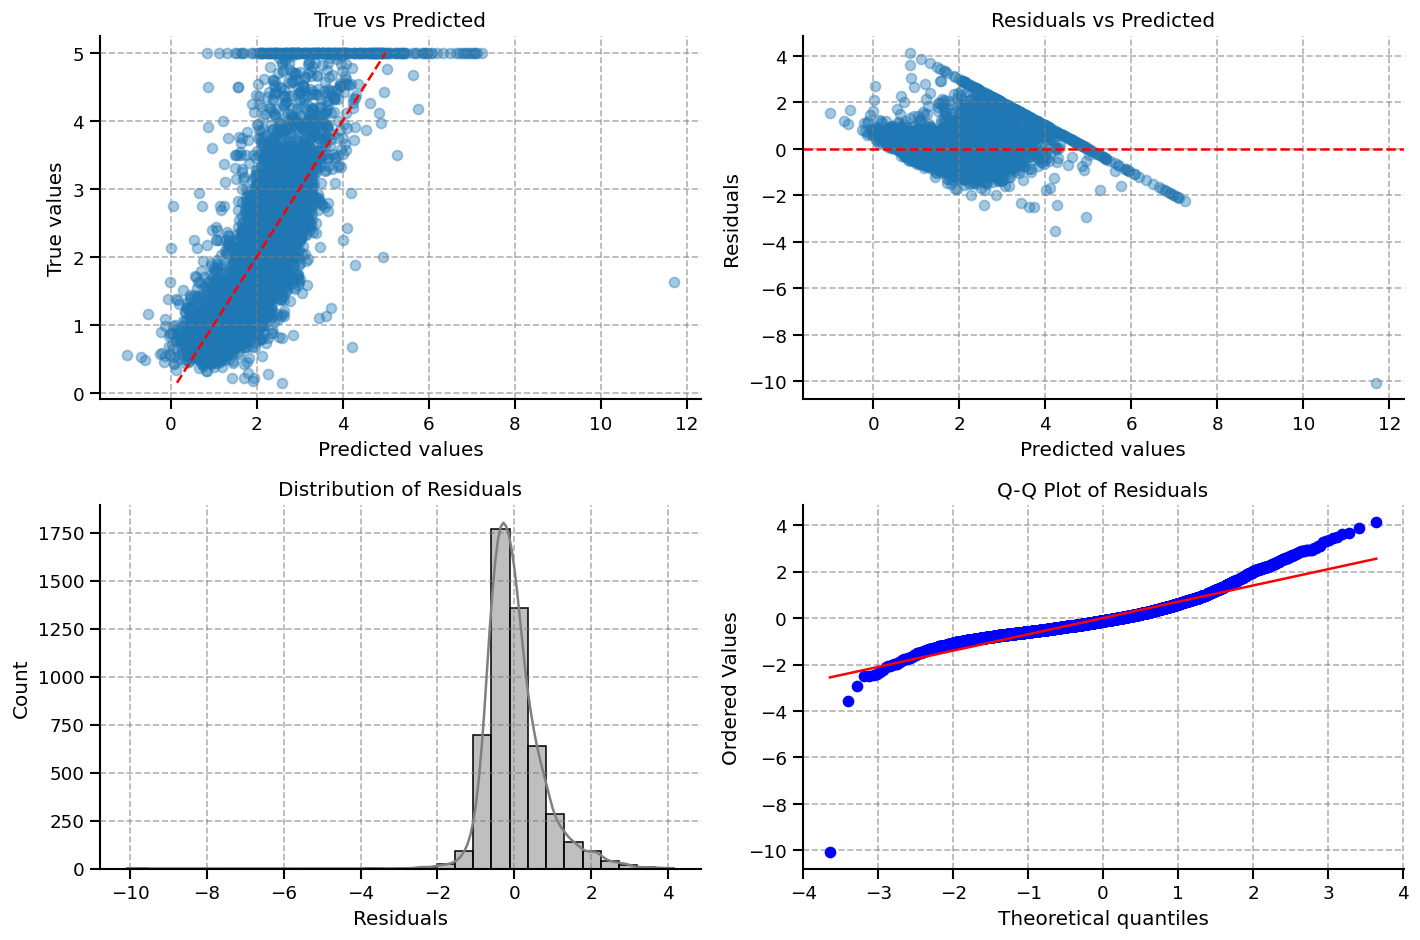

In [8]:
# Tworzenie zestawu wykresów
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. y_true vs y_pred
axes[0, 0].scatter(y_pred, y_test, alpha=0.4)
axes[0, 0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
axes[0, 0].set_xlabel("Predicted values")
axes[0, 0].set_ylabel("True values")
axes[0, 0].set_title("True vs Predicted")
axes[0, 0].grid(True, linestyle="--", alpha=0.6)

# 2. Reszt vs y_pred
axes[0, 1].scatter(y_pred, residuals, alpha=0.4)
axes[0, 1].axhline(0, linestyle='--', color='red')
axes[0, 1].set_xlabel("Predicted values")
axes[0, 1].set_ylabel("Residuals")
axes[0, 1].set_title("Residuals vs Predicted")
axes[0, 1].grid(True, linestyle="--", alpha=0.6)

# 3. Histogram reszt
sns.histplot(residuals, kde=True, ax=axes[1, 0], bins=30, color="gray")
axes[1, 0].set_title("Distribution of Residuals")
axes[1, 0].set_xlabel("Residuals")
axes[1, 0].grid(True, linestyle="--", alpha=0.6)

# 4. Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot of Residuals")
axes[1, 1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


**Interpretacja**:

Powyższy zestaw wykresów przedstawia kluczowe aspekty diagnostyczne modelu regresji liniowej na zbiorze **California Housing**:

1. **True vs Predicted**: pokazuje, jak dobrze przewidywane wartości odpowiadają rzeczywistym; im bliżej czerwonej linii `y = x`, tym lepsze dopasowanie.

2. **Reszty vs Przewidywania**: idealnie rozrzucone losowo wokół 0 — brak wzoru sugeruje poprawny model liniowy.

3. **Histogram reszt**: pozwala ocenić rozkład błędów — tutaj dość symetryczny, z lekkim ogonem.

4. **Q-Q plot**: weryfikuje, czy reszty mają rozkład normalny — lekkie odchylenia przy ogonach wskazują na pewne odchylenia od normalności.

## Graficzna ocena (Random Forest)

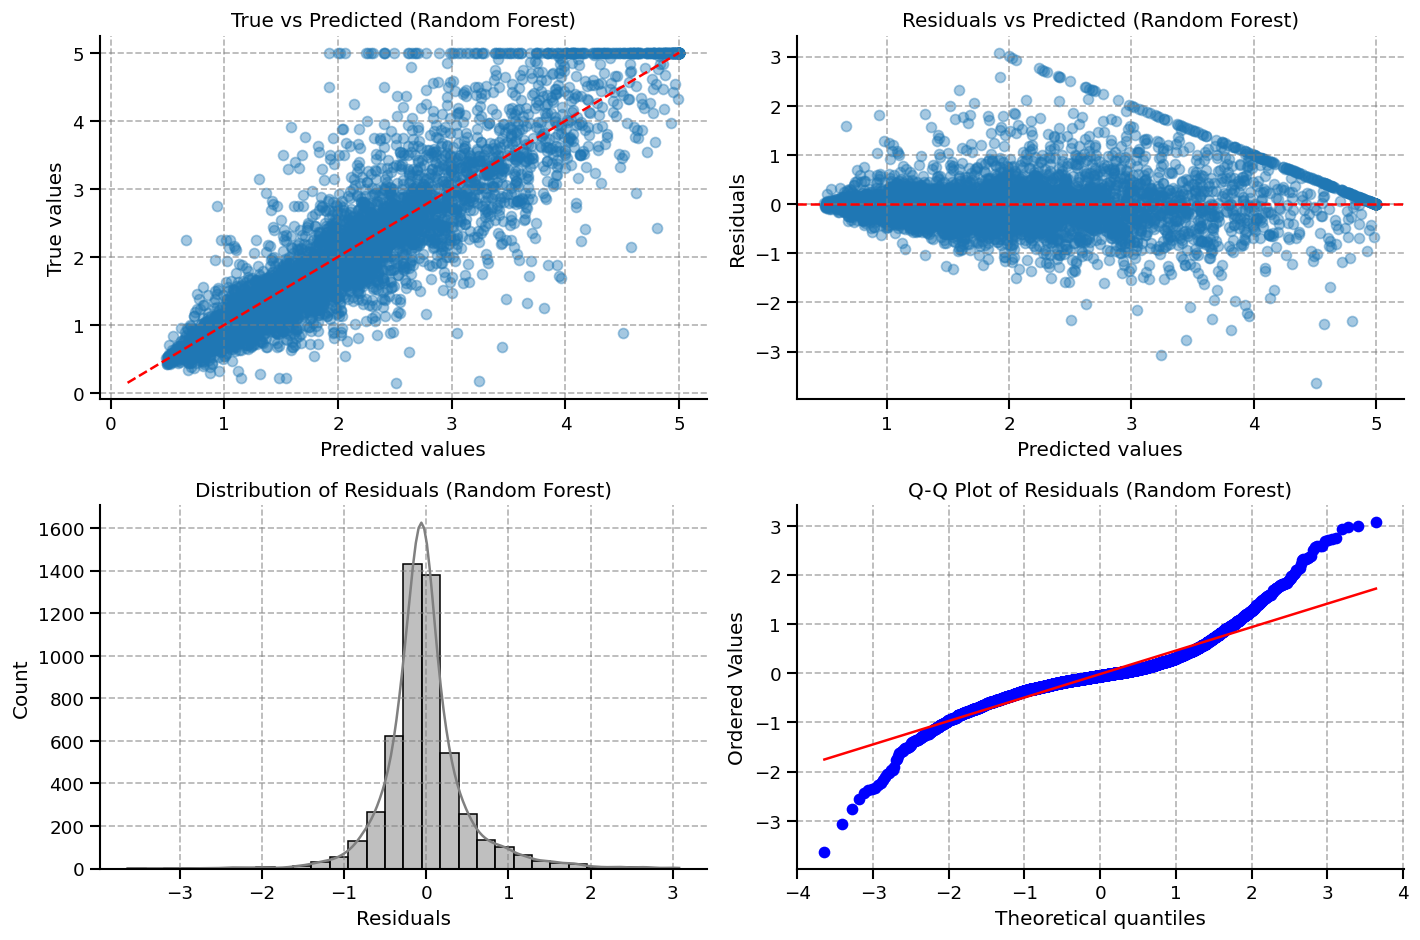

In [9]:
# Tworzenie zestawu wykresów
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. y_true vs y_pred
axes[0, 0].scatter(rf_pred, y_test, alpha=0.4)
axes[0, 0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
axes[0, 0].set_xlabel("Predicted values")
axes[0, 0].set_ylabel("True values")
axes[0, 0].set_title("True vs Predicted (Random Forest)")
axes[0, 0].grid(True, linestyle="--", alpha=0.6)

# 2. Reszty vs y_pred
axes[0, 1].scatter(rf_pred, rf_residuals, alpha=0.4)
axes[0, 1].axhline(0, linestyle='--', color='red')
axes[0, 1].set_xlabel("Predicted values")
axes[0, 1].set_ylabel("Residuals")
axes[0, 1].set_title("Residuals vs Predicted (Random Forest)")
axes[0, 1].grid(True, linestyle="--", alpha=0.6)

# 3. Histogram reszt
sns.histplot(rf_residuals, kde=True, ax=axes[1, 0], bins=30, color="gray")
axes[1, 0].set_title("Distribution of Residuals (Random Forest)")
axes[1, 0].set_xlabel("Residuals")
axes[1, 0].grid(True, linestyle="--", alpha=0.6)

# 4. Q-Q plot
stats.probplot(rf_residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot of Residuals (Random Forest)")
axes[1, 1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

**Interpretacja**:
  
Powyżej widzisz zestaw wykresów diagnostycznych dla modelu **Random Forest Regressor**:

1. **True vs Predicted** – większość punktów blisko przekątnej: dobry poziom dopasowania, ale możliwe pewne lokalne przeszacowania lub niedoszacowania.

2. **Reszty vs Predykcje** – mniej strukturalne wzory niż w regresji liniowej, co sugeruje lepsze dopasowanie nieliniowych zależności.

3. **Histogram reszt** – rozkład dość symetryczny, ale nieidealnie normalny, wskazujący na różne poziomy błędów w zależności od zakresu.

4. **Q-Q plot** – wyraźniejsze odchylenia od rozkładu normalnego, co jest typowe dla modeli drzewiastych.

## Nowości

Od którejś wersji w pakiecie sklearn jest też funkcja: **PredictionErrorDisplay**, zatem nie trzeba korzystać ze Scater Plot, poniżej wykres dla wyników z poprzedniego punktu.

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.PredictionErrorDisplay.html# 

In [10]:
from sklearn.metrics import PredictionErrorDisplay

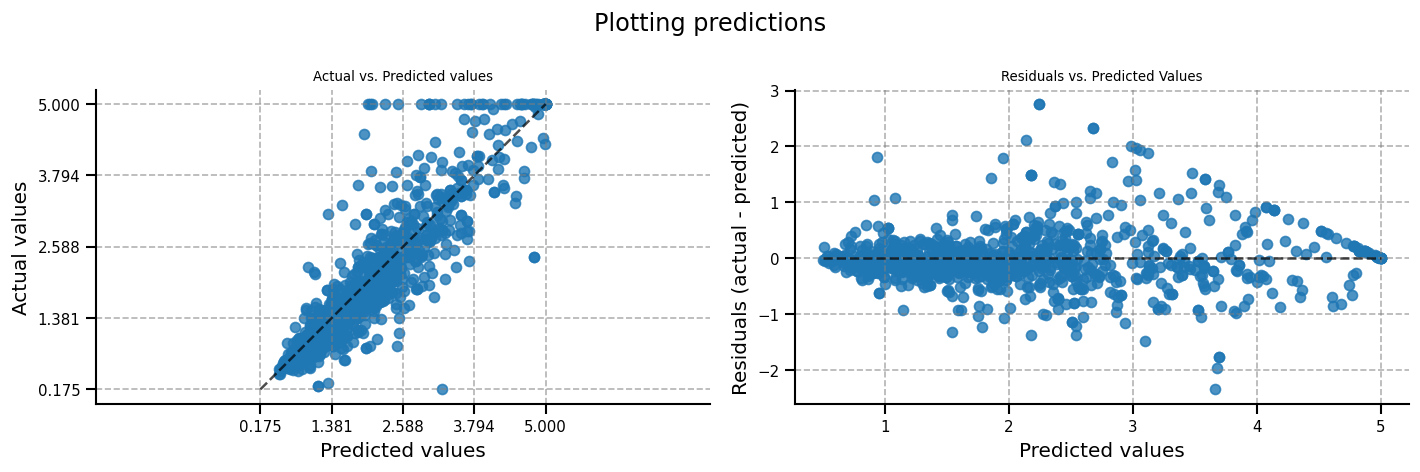

In [14]:
fig, axs = plt.subplots(ncols=2, figsize=(12, 4))
PredictionErrorDisplay.from_predictions(
    y_true=y_test,
    y_pred=rf_pred,
    kind="actual_vs_predicted",
    ax=axs[0],
)

axs[0].set_title("Actual vs. Predicted values", fontsize=8)
axs[0].tick_params(axis='both', labelsize=9)
axs[0].grid(True, linestyle="--", alpha=0.6)

PredictionErrorDisplay.from_predictions(
    y_true=y_test,
    y_pred=rf_pred,
    kind="residual_vs_predicted",
    ax=axs[1],
)

axs[1].set_title("Residuals vs. Predicted Values", fontsize=8)
axs[1].tick_params(axis='both', labelsize=9)
axs[1].grid(True, linestyle="--", alpha=0.6)

fig.suptitle("Plotting predictions")
plt.tight_layout()
plt.show()

# Zadanie

Usuń ocenzurowane domy i przelicz jeszcze raz modele, metryki i stwórz wykresy.

In [12]:
mask = y < 5.0
X = X[mask] # pochodzi z data, ma te same indeksy co y
y = y[mask]